# Does Sleep Time Affect How Often People Want Coffee?

**C-DE211 — Data Analysis — Project 3**
**Team:** [Name 1], [Name 2], [Name 3], [Name 4]
**Dataset:** Global Coffee Health Dataset (Kaggle) — `synthetic_coffee_health_10000.csv`

---

### Research question
Is there a relationship between the number of hours a person sleeps and how much coffee they drink per day?

### Hypothesis
- **H₀ (null):** Sleep hours have *no* relationship with daily coffee intake.
- **H₁ (alternative):** People who sleep less drink *more* coffee per day (negative correlation).

### Significance level
α = 0.05


## 1. Setup & load the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Reproducibility
np.random.seed(42)

In [ ]:
# Load the dataset
df = pd.read_csv('synthetic_coffee_health_10000.csv')
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Dataset shape: 10,000 rows × 16 columns


,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,NaN,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,NaN,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1


## 2. Understand the data

Before we analyze anything we need to know what we're working with — column types, missing values, ranges.

In [ ]:
# Data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       10000 non-null  int64  
 1   Age                      10000 non-null  int64  
 2   Gender                   10000 non-null  str    
 3   Country                  10000 non-null  str    
 4   Coffee_Intake            10000 non-null  float64
 5   Caffeine_mg              10000 non-null  float64
 6   Sleep_Hours              10000 non-null  float64
 7   Sleep_Quality            10000 non-null  str    
 8   BMI                      10000 non-null  float64
 9   Heart_Rate               10000 non-null  int64  
 10  Stress_Level             10000 non-null  str    
 11  Physical_Activity_Hours  10000 non-null  float64
 12  Health_Issues            4059 non-null   str    
 13  Occupation               10000 non-null  str    
 14  Smoking                  10000 non

In [ ]:
# Missing values per column
missing = df.isna().sum()
missing[missing > 0]

Health_Issues    5941
dtype: int64

**Observation:** `Health_Issues` has 5,941 missing values — these represent people with *no* health issues (the column only records issues if any exist). We'll fill this with `'None'` instead of dropping rows.

In [ ]:
# Fill Health_Issues NaN with 'None' (means no reported issue)
df['Health_Issues'] = df['Health_Issues'].fillna('None')
print("After filling:")
print(df['Health_Issues'].value_counts())

After filling:
Health_Issues
None        5941
Mild        3579
Moderate     463
Severe        17
Name: count, dtype: int64


In [ ]:
# Summary statistics for numeric columns
df.describe().round(2)

,ID,Age,Coffee_Intake,Caffeine_mg,Sleep_Hours,BMI,Heart_Rate,Physical_Activity_Hours,Smoking,Alcohol_Consumption
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.0,10000.00
mean,5000.50,34.95,2.51,238.41,6.64,23.99,70.62,7.49,0.2,0.30
std,2886.90,11.16,1.45,137.75,1.22,3.91,9.82,4.32,0.4,0.46
min,1.00,18.00,0.00,0.00,3.00,15.00,50.00,0.00,0.0,0.00
25%,2500.75,26.00,1.50,138.75,5.80,21.30,64.00,3.70,0.0,0.00
50%,5000.50,34.00,2.50,235.40,6.60,24.00,71.00,7.50,0.0,0.00
75%,7500.25,43.00,3.50,332.02,7.50,26.60,77.00,11.20,0.0,1.00
max,10000.00,80.00,8.20,780.30,10.00,38.20,109.00,15.00,1.0,1.00


In [ ]:
# Categorical breakdown
for col in ['Gender', 'Sleep_Quality', 'Stress_Level', 'Occupation']:
    print(f"\n{col}:")
    print(df[col].value_counts())


Gender:
Gender
Female    5001
Male      4773
Other      226
Name: count, dtype: int64

Sleep_Quality:
Sleep_Quality
Good         5637
Fair         2050
Excellent    1352
Poor          961
Name: count, dtype: int64

Stress_Level:
Stress_Level
Low       6989
Medium    2050
High       961
Name: count, dtype: int64

Occupation:
Occupation
Office        2073
Other         2038
Student       1968
Healthcare    1964
Service       1957
Name: count, dtype: int64


## 3. Exploratory data analysis

Let's look at the two main variables — sleep hours and coffee intake — before testing any hypothesis.

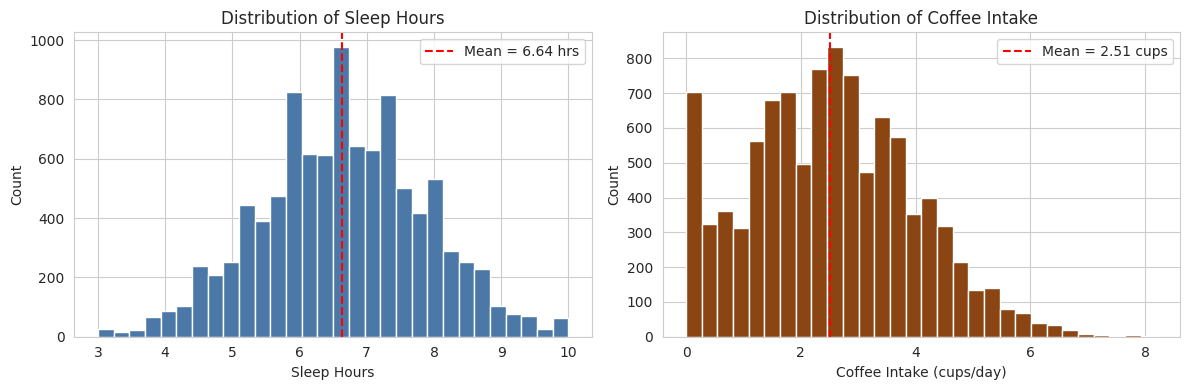

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Sleep hours distribution
axes[0].hist(df['Sleep_Hours'], bins=30, color='#4C78A8', edgecolor='white')
axes[0].axvline(df['Sleep_Hours'].mean(), color='red', linestyle='--',
                label=f"Mean = {df['Sleep_Hours'].mean():.2f} hrs")
axes[0].set_xlabel('Sleep Hours')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Sleep Hours')
axes[0].legend()

# Coffee intake distribution
axes[1].hist(df['Coffee_Intake'], bins=30, color='#8B4513', edgecolor='white')
axes[1].axvline(df['Coffee_Intake'].mean(), color='red', linestyle='--',
                label=f"Mean = {df['Coffee_Intake'].mean():.2f} cups")
axes[1].set_xlabel('Coffee Intake (cups/day)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Coffee Intake')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_distributions.png', bbox_inches='tight')
plt.show()

**Observation:** Sleep hours are roughly normally distributed around ~7 hours. Coffee intake is right-skewed — most people drink 1–4 cups, with a tail up to 8 cups/day.

## 4. The key relationship — sleep vs coffee

This is the visual that answers the hypothesis at a glance.

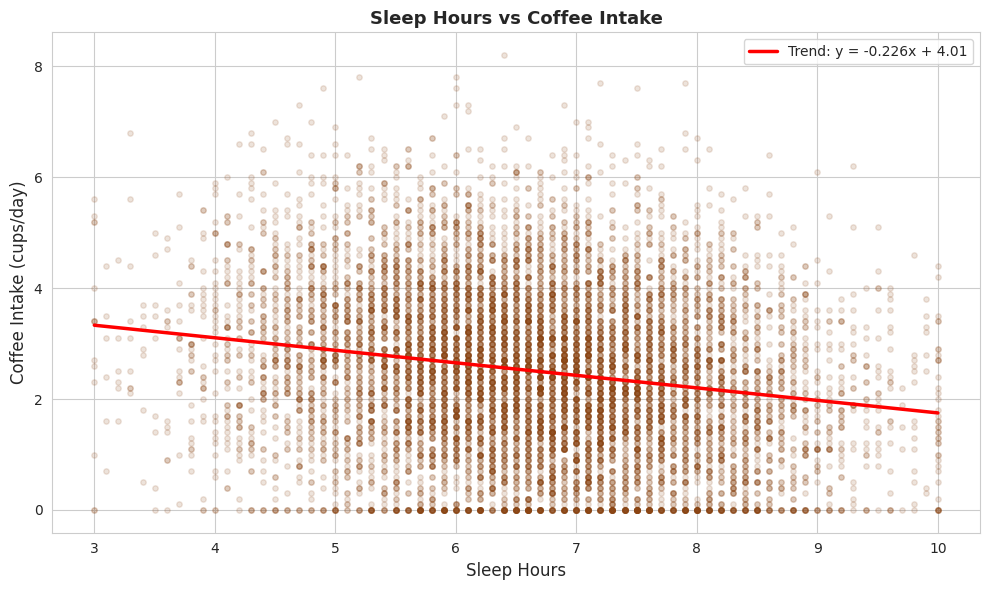

In [ ]:
plt.figure(figsize=(10, 6))

# Scatter with transparency to show density
plt.scatter(df['Sleep_Hours'], df['Coffee_Intake'],
            alpha=0.15, s=15, color='#8B4513')

# Regression line
z = np.polyfit(df['Sleep_Hours'], df['Coffee_Intake'], 1)
x_line = np.linspace(df['Sleep_Hours'].min(), df['Sleep_Hours'].max(), 100)
plt.plot(x_line, np.poly1d(z)(x_line), color='red', linewidth=2.5,
         label=f'Trend: y = {z[0]:.3f}x + {z[1]:.2f}')

plt.xlabel('Sleep Hours', fontsize=12)
plt.ylabel('Coffee Intake (cups/day)', fontsize=12)
plt.title('Sleep Hours vs Coffee Intake', fontsize=13, fontweight='bold')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('fig_scatter.png', bbox_inches='tight')
plt.show()

**Observation:** The trend line slopes downward — more sleep is associated with less coffee. The effect looks modest; there's lots of scatter, meaning sleep isn't the *only* factor driving coffee consumption.

## 5. Grouping people by sleep category

To make the relationship easier to see, let's split people into three groups:
- **Short sleepers** (< 6 hrs)
- **Normal sleepers** (6–8 hrs)
- **Long sleepers** (> 8 hrs)

In [ ]:
def sleep_group(h):
    if h < 6: return 'Short (<6h)'
    elif h <= 8: return 'Normal (6-8h)'
    else: return 'Long (>8h)'

df['Sleep_Group'] = df['Sleep_Hours'].apply(sleep_group)
order = ['Short (<6h)', 'Normal (6-8h)', 'Long (>8h)']

# Count + mean in each group
print(df.groupby('Sleep_Group')['Coffee_Intake'].agg(['count','mean','std']).round(3).reindex(order))

               count   mean    std
Sleep_Group                       
Short (<6h)     2878  2.838  1.471
Normal (6-8h)   5854  2.450  1.424
Long (>8h)      1268  2.036  1.352


/tmp/ipykernel_119/1601483501.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Sleep_Group', y='Coffee_Intake',


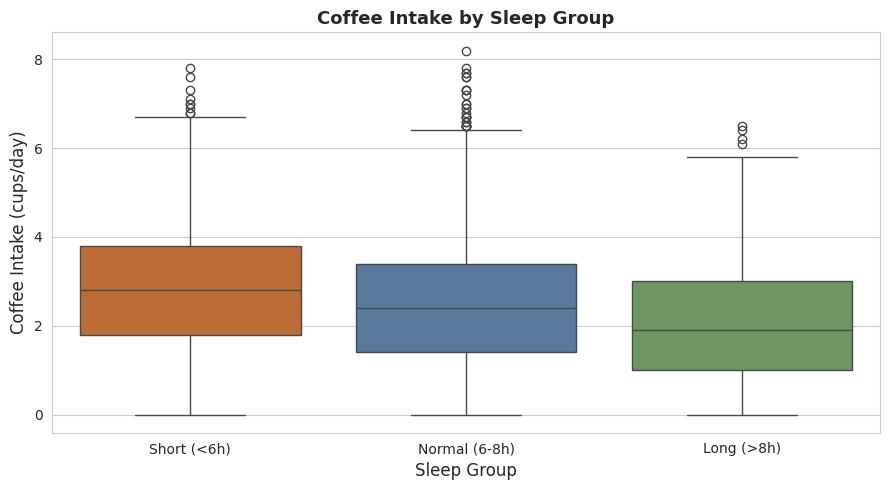

In [ ]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='Sleep_Group', y='Coffee_Intake',
            order=order, palette=['#D2691E', '#4C78A8', '#6A9F58'])
plt.xlabel('Sleep Group', fontsize=12)
plt.ylabel('Coffee Intake (cups/day)', fontsize=12)
plt.title('Coffee Intake by Sleep Group', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_boxplot.png', bbox_inches='tight')
plt.show()

**Observation:** The boxplot makes the pattern clear. Median coffee intake drops from short sleepers → normal → long sleepers. Short sleepers consume noticeably more.

## 6. Wider correlation check

Before committing to the main test, let's see how coffee intake correlates with *all* the numeric variables — we don't want to miss a bigger driver.

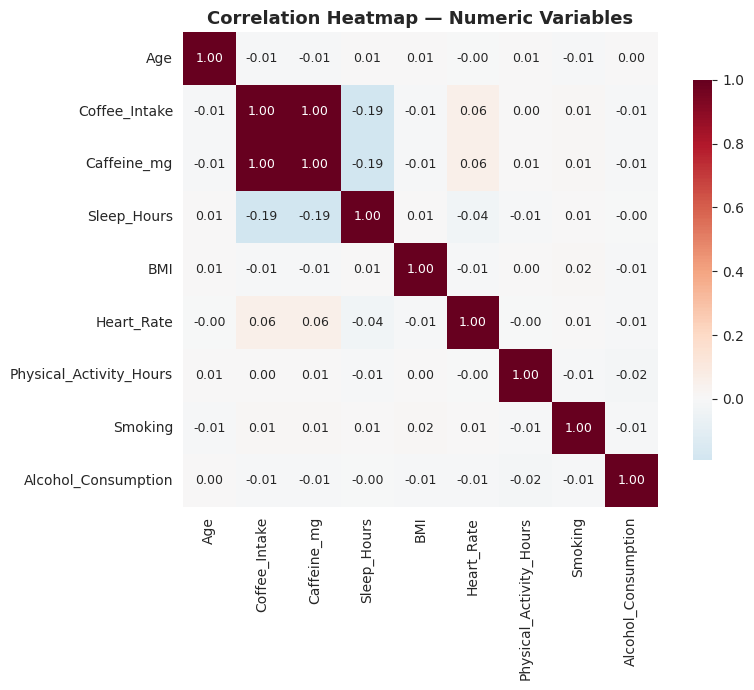

In [ ]:
numeric_cols = ['Age', 'Coffee_Intake', 'Caffeine_mg', 'Sleep_Hours',
                'BMI', 'Heart_Rate', 'Physical_Activity_Hours',
                'Smoking', 'Alcohol_Consumption']
corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f',
            square=True, cbar_kws={'shrink': 0.8}, annot_kws={'size': 9})
plt.title('Correlation Heatmap — Numeric Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_heatmap.png', bbox_inches='tight')
plt.show()

**Observation:** `Caffeine_mg` is almost perfectly correlated with `Coffee_Intake` (they measure the same thing). Apart from that, `Sleep_Hours` has the strongest relationship with coffee intake — confirming it's the right variable to focus on.

## 7. Hypothesis testing

### Step 1 — State the hypotheses
- **H₀:** ρ = 0 (no correlation between sleep hours and coffee intake)
- **H₁:** ρ < 0 (negative correlation — less sleep, more coffee)

### Step 2 — Choose the test
- **Pearson correlation** — tests linear relationship
- **Spearman correlation** — rank-based, doesn't assume linearity
- **One-way ANOVA** — tests whether mean coffee intake differs across sleep groups

### Step 3 — Set α = 0.05

### Step 4 — Run the tests

In [ ]:
# ------- Pearson -------
pearson_r, pearson_p = stats.pearsonr(df['Sleep_Hours'], df['Coffee_Intake'])
print(f"Pearson correlation:  r = {pearson_r:.4f},  p = {pearson_p:.4g}")

# ------- Spearman -------
spearman_r, spearman_p = stats.spearmanr(df['Sleep_Hours'], df['Coffee_Intake'])
print(f"Spearman correlation: r = {spearman_r:.4f},  p = {spearman_p:.4g}")

# ------- ANOVA across sleep groups -------
groups = [df[df['Sleep_Group']==g]['Coffee_Intake'] for g in order]
f_stat, anova_p = stats.f_oneway(*groups)
print(f"\nOne-way ANOVA:        F = {f_stat:.4f},  p = {anova_p:.4g}")

Pearson correlation:  r = -0.1903,  p = 3.534e-82
Spearman correlation: r = -0.1901,  p = 5.677e-82

One-way ANOVA:        F = 150.8651,  p = 2.815e-65


In [ ]:
# Verdict table
alpha = 0.05
verdicts = pd.DataFrame({
    'Test': ['Pearson correlation', 'Spearman correlation', 'One-way ANOVA'],
    'Statistic': [f'r = {pearson_r:.4f}', f'r = {spearman_r:.4f}', f'F = {f_stat:.2f}'],
    'p-value': [f'{pearson_p:.2e}', f'{spearman_p:.2e}', f'{anova_p:.2e}'],
    'Reject H₀?': [pearson_p < alpha, spearman_p < alpha, anova_p < alpha]
})
verdicts

,Test,Statistic,p-value,Reject H₀?
0,Pearson correlation,r = -0.1903,3.53e-82,True
1,Spearman correlation,r = -0.1901,5.68e-82,True
2,One-way ANOVA,F = 150.87,2.81e-65,True


**Interpretation:**
- All three tests reject H₀ with p-values far below 0.05.
- Pearson r ≈ −0.19 — a **weak but highly significant negative correlation**.
- Spearman matches Pearson closely → the relationship isn't driven by a few outliers.
- ANOVA confirms the three sleep groups have genuinely different mean coffee intakes.

### Effect size
Even though the correlation is statistically significant, r² ≈ 0.036 means sleep hours explain only about **3.6%** of the variation in coffee intake. Statistically real, practically modest.

In [ ]:
# Pairwise comparison of means
means = df.groupby('Sleep_Group')['Coffee_Intake'].mean().reindex(order)
print("Mean coffee intake per group:")
for g in order:
    print(f"  {g:<15} {means[g]:.3f} cups/day")

diff = means['Short (<6h)'] - means['Long (>8h)']
pct  = diff / means['Long (>8h)'] * 100
print(f"\nShort sleepers drink {diff:.2f} more cups/day than long sleepers ({pct:.1f}% more).")

Mean coffee intake per group:
  Short (<6h)     2.838 cups/day
  Normal (6-8h)   2.450 cups/day
  Long (>8h)      2.036 cups/day

Short sleepers drink 0.80 more cups/day than long sleepers (39.4% more).


## 8. Digging deeper — does it hold across subgroups?

A good analysis doesn't stop at the headline test. Does this relationship hold equally for everyone?

In [ ]:
# By gender
print("Correlation by gender:")
for g in df['Gender'].unique():
    sub = df[df['Gender']==g]
    r, p = stats.pearsonr(sub['Sleep_Hours'], sub['Coffee_Intake'])
    print(f"  {g:<10} n={len(sub):<5} r={r:+.3f}  p={p:.2e}")

# By stress level
print("\nCorrelation by stress level:")
for s in ['Low','Medium','High']:
    sub = df[df['Stress_Level']==s]
    r, p = stats.pearsonr(sub['Sleep_Hours'], sub['Coffee_Intake'])
    print(f"  {s:<8} n={len(sub):<5} r={r:+.3f}  p={p:.2e}")

# By occupation
print("\nCorrelation by occupation:")
for o in df['Occupation'].unique():
    sub = df[df['Occupation']==o]
    r, p = stats.pearsonr(sub['Sleep_Hours'], sub['Coffee_Intake'])
    print(f"  {o:<12} n={len(sub):<5} r={r:+.3f}  p={p:.2e}")

Correlation by gender:
  Male       n=4773  r=-0.181  p=2.59e-36
  Female     n=5001  r=-0.197  p=6.84e-45
  Other      n=226   r=-0.248  p=1.68e-04

Correlation by stress level:
  Low      n=6989  r=-0.144  p=8.35e-34
  Medium   n=2050  r=-0.040  p=7.27e-02
  High     n=961   r=+0.022  p=4.89e-01

Correlation by occupation:
  Other        n=2038  r=-0.172  p=5.79e-15
  Service      n=1957  r=-0.222  p=2.31e-23
  Office       n=2073  r=-0.150  p=6.48e-12
  Student      n=1968  r=-0.191  p=1.35e-17
  Healthcare   n=1964  r=-0.221  p=4.57e-23


**Observation:** The negative correlation is consistent across every subgroup — gender, stress level, and occupation. The effect isn't being driven by one demographic.

/tmp/ipykernel_119/2016367960.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Sleep_Quality', y='Coffee_Intake',


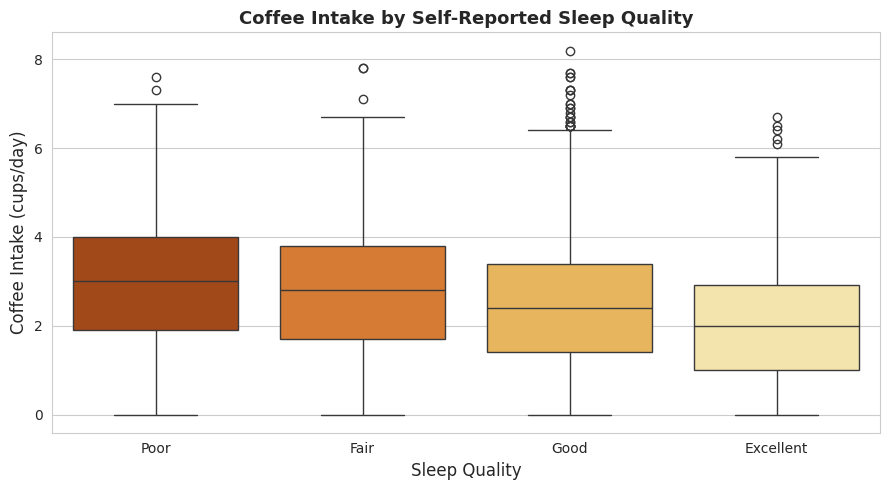


ANOVA across sleep quality groups: F=106.92, p=3.90e-68


In [ ]:
# Sleep QUALITY vs sleep QUANTITY — which matters more?
plt.figure(figsize=(9, 5))
sq_order = ['Poor', 'Fair', 'Good', 'Excellent']
sns.boxplot(data=df, x='Sleep_Quality', y='Coffee_Intake',
            order=sq_order, palette='YlOrBr_r')
plt.xlabel('Sleep Quality', fontsize=12)
plt.ylabel('Coffee Intake (cups/day)', fontsize=12)
plt.title('Coffee Intake by Self-Reported Sleep Quality', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_quality.png', bbox_inches='tight')
plt.show()

# ANOVA for sleep quality too
quality_groups = [df[df['Sleep_Quality']==q]['Coffee_Intake'] for q in sq_order]
f_q, p_q = stats.f_oneway(*quality_groups)
print(f"\nANOVA across sleep quality groups: F={f_q:.2f}, p={p_q:.2e}")

**Observation:** Sleep *quality* shows a similar pattern — people reporting poor sleep drink more coffee than those reporting excellent sleep. Both quantity and quality matter.

## 9. Conclusion

**Summary of findings:**
1. Sleep hours and coffee intake are negatively correlated: Pearson r = −0.19, p < 0.001.
2. Short sleepers (<6 hrs) drink about 40% more coffee per day than long sleepers (>8 hrs) — 2.84 vs 2.04 cups.
3. The effect is statistically significant but modest (r² ≈ 3.6%) — sleep is *one* factor among many.
4. The pattern holds across genders, stress levels, and occupations.
5. Sleep quality shows the same pattern as sleep quantity.

**Verdict:** We **reject H₀** and accept H₁. There is a real, consistent, negative relationship between sleep and coffee consumption in this dataset — but it's one piece of a larger picture.

**Caveats (discussed fully in the report):**
- The dataset is synthetic (generated, not real survey data), so results shouldn't be extrapolated to real populations without validation.
- Correlation is not causation — tired people might drink more coffee, *or* coffee might disrupt sleep. Our test can't distinguish the two.
- No Egypt-specific records in this dataset.